# Week 36, Tuesday session: the bias-variance tradeoff and cross-validation in practice

**FYS-STK3155/4155, Tuesday September 1, 2026**

This is the companion notebook to Monday's lecture (`week36slides.pdf`) and
Tuesday's steering deck (`week36tuesday.pdf`). We work through **two cases
only**, deliberately:

1. **Case 1:** the bias-variance decomposition, Eq. (2.47) of the book, measured
   with the bootstrap — reproduced, then stress-tested;
2. **Case 2:** $k$-fold cross-validation for the Ridge penalty $\lambda$ (and for
   the polynomial degree), written by hand and validated against `scikit-learn`.

All seeds are 2026, so your figures reproduce the lecture figures exactly.
Work in pairs or small groups; the plenary checkpoints are on the Tuesday
slides. The code you write here is directly reusable in this week's exercise
set (deadline Friday September 4) and in Project 1.

Reading: Chapter 2, Sections 2.9–2.12 (and 2.3–2.8 for the statistical toolbox).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample
from scipy.stats import norm

# the color palette used in the weekly slides
BLUE, RED, YELLOW = "#004488", "#BB5566", "#DDAA33" 

## Warm-up (from the Tuesday slides, first ~20 minutes)

Before touching the keyboard, make sure your group can answer the three
warm-ups from the steering deck:

1. **The three terms in your own words** — which term of Eq. (2.47) is which,
   and which one does Ridge attack?
2. **Read the code, not the formula** — why `axis=1` in the bias line, and why
   does the measured "bias" absorb $\sigma^2$?
3. **Predict before you compute** — what happens to bias, variance and the
   minimum when (a) $n: 40 \to 400$ and (b) $\sigma: 0.1 \to 0.3$? Write your
   predictions down; you will check them below.

Recall the identity we derived on Monday (Eq. (2.47) of the book):

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \underbrace{\frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2}_{\mathrm{Bias}^2}
+ \underbrace{\frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2}_{\mathrm{Var}[\tilde{\boldsymbol{y}}]}
+ \sigma^2 .
$$

## Case 1: the bias-variance decomposition, owned

The expectation over training sets in Eq. (2.47) is manufactured by the
**bootstrap**: we resample the training data with replacement, refit the model
on each resample, and average. The code below is exactly the code behind
Monday's figure (`week36_bias_variance.pdf`) and follows Section 2.10 of the
book.

### Step 1: reproduce the lecture figure

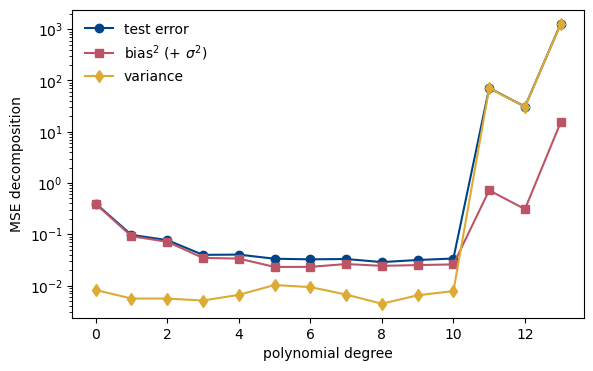

degree  0: error 0.3980  bias^2 0.3898  var 0.0082  sum 0.3980
degree  4: error 0.0401  bias^2 0.0336  var 0.0066  sum 0.0401
degree  8: error 0.0286  bias^2 0.0242  var 0.0044  sum 0.0286
degree 13: error 1276.6977  bias^2 15.3057  var 1261.3920  sum 1276.6977


In [2]:
np.random.seed(2026)
n, n_bootstraps, maxdegree = 40, 100, 14

x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=2026)

error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
for degree in range(maxdegree):
    model = make_pipeline(PolynomialFeatures(degree=degree),
                          LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    for i in range(n_bootstraps):
        x_, y_ = resample(x_train, y_train)
        y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

    # Expectations over training sets are averages along axis 1;
    # keepdims=True preserves the column shape and is essential
    # for the bias to come out right.
    error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), error, "o-", color=BLUE, label="test error")
ax.plot(range(maxdegree), bias, "s-", color=RED, label=r"bias$^2$ (+ $\sigma^2$)")
ax.plot(range(maxdegree), variance, "d-", color=YELLOW, label="variance")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.legend(frameon=False)
plt.show()

for d in (0, 4, 8, maxdegree - 1):
    print(f"degree {d:2d}: error {error[d]:.4f}  bias^2 {bias[d]:.4f}  "
          f"var {variance[d]:.4f}  sum {bias[d] + variance[d]:.4f}")

**Checkpoint questions** (discuss before moving on):

- At degree 0 the model predicts a constant, so its variance is tiny and the
  bias$^2 \approx 0.39$ is essentially the variance of $f$ itself. Why?
- The error and the sum bias$^2$ + variance agree to all printed digits. Where
  did $\sigma^2$ go? (Warm-up 2 has the answer.)
- The minimum is *broad*, degrees 5–9 — model selection rarely has a sharp
  answer.

### Step 2: vary the data size

To explore, we wrap the sweep in a function. Predictions from warm-up 3 in
hand, run $n = 100$ and $n = 400$.

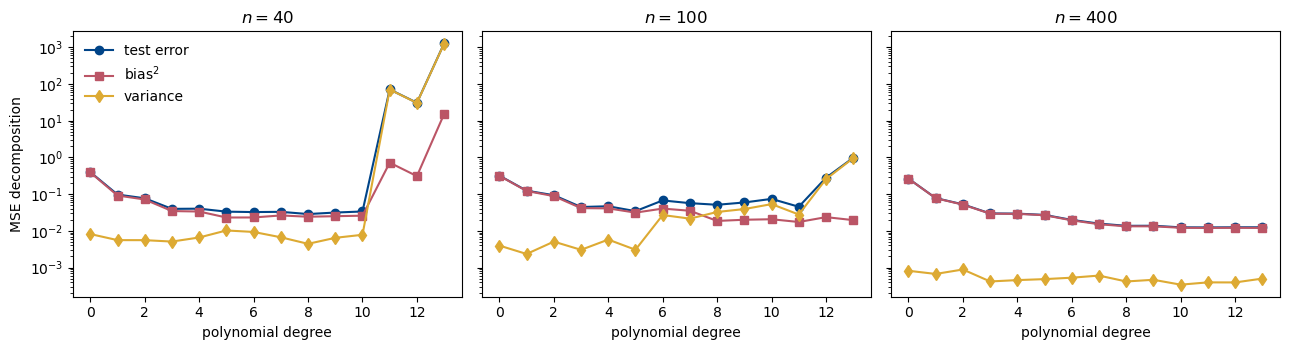

In [3]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

Compare with your prediction: more data postpones the variance explosion
(the minimum moves right — a richer model becomes affordable), while the bias
curve, a property of the model family and not of $n$, barely moves.

### Step 3: vary the noise

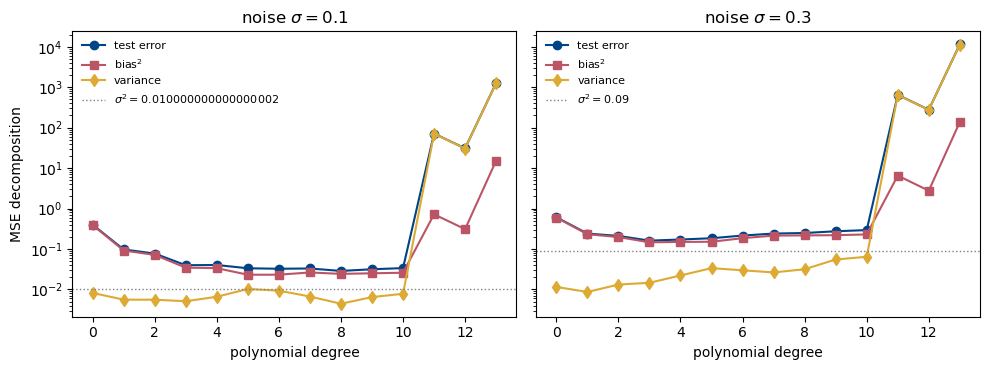

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, noise_ in zip(axes, (0.1, 0.3)):
    err, b2, var = bias_variance_sweep(n=40, noise=noise_)
    ax.plot(range(14), err, "o-", color=BLUE, label="test error")
    ax.plot(range(14), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(14), var, "d-", color=YELLOW, label="variance")
    ax.axhline(noise_**2, color="gray", ls=":", lw=1,
               label=rf"$\sigma^2 = {noise_**2}$")
    ax.set_yscale("log")
    ax.set_title(rf"noise $\sigma = {noise_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
for ax in axes:
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

The floor rises with $\sigma^2$ (nine times higher for $\sigma=0.3$) and the
variance term scales up, while the bias$^2$ term is essentially unchanged —
noisier data favour simpler models, and the minimum shifts left.

### Step 4: the tradeoff as a dial — Ridge at fixed high degree

At degree 12 plain OLS is deep in the variance-explosion region. Now turn the
$\lambda$ dial and watch Eq. (2.47) rebalance.

In [5]:
degree_fixed = 12
lams = [0.0, 1e-4, 1e-1, 10.0]

print(f"degree {degree_fixed}, n = 40, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                       LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg),
                                                StandardScaler(),
                                                Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1,
                                       make_model=mk)
    d = degree_fixed
    label = "OLS" if lam == 0.0 else f"{lam:g}"
    print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}")

degree 12, n = 40, 100 bootstraps
  lambda       error      bias^2    variance
     OLS     30.8046      0.3090     30.4956
  0.0001      0.0338      0.0272      0.0067
     0.1      0.0289      0.0228      0.0060
      10      0.1020      0.0979      0.0041


     OLS     30.8046      0.3090     30.4956


  0.0001      0.0338      0.0272      0.0067


     0.1      0.0289      0.0228      0.0060


      10      0.1020      0.0979      0.0041


**Checkpoint:** as $\lambda$ grows the variance falls by orders of magnitude
while the bias creeps up — the tradeoff has become a dial you control. Which
$\lambda$ gives the smallest total error at degree 12, and does it beat plain
OLS at degree 6 from Step 1? (This is precisely the game cross-validation
automates in Case 2.)

---

## Case 2: cross-validation — choosing $\lambda$ without touching the test set

A single train/test split wastes data and depends on which points landed
where. **$k$-fold cross-validation** (Section 2.12): shuffle, split into $k$
folds, let each fold be the test set once, average the $k$ scores.

### Step 1: your own 5-fold loop

The data are $y = 3x^2 + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0,1)$,
fitted by a degree-6 polynomial with Ridge. Note that the scaler is fitted
**inside** each fold, on the training folds only — Monday's "subtle leak"
warm-up explains why this matters.

In [6]:
rng = np.random.default_rng(2026)
n = 100
x = rng.standard_normal(n)
y = 3 * x**2 + rng.standard_normal(n)     # noise variance is 1

nlambdas = 100
lambdas = np.logspace(-3, 5, nlambdas)
k = 5
kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
poly = PolynomialFeatures(degree=6)

scores_KFold = np.zeros((nlambdas, k))
for i, lmb in enumerate(lambdas):
    for j, (train_inds, test_inds) in enumerate(kfold.split(x)):
        xtrain, ytrain = x[train_inds], y[train_inds]
        xtest, ytest = x[test_inds], y[test_inds]

        Xtrain = poly.fit_transform(xtrain[:, np.newaxis])
        Xtest = poly.transform(xtest[:, np.newaxis])
        scaler = StandardScaler().fit(Xtrain)   # fitted on the training folds only

        ridge = Ridge(alpha=lmb)
        ridge.fit(scaler.transform(Xtrain), ytrain)
        ypred = ridge.predict(scaler.transform(Xtest))
        scores_KFold[i, j] = np.mean((ypred - ytest)**2)
mse_KFold = np.mean(scores_KFold, axis=1)

### Step 2: validate against `cross_val_score`

The same computation in three lines, with the preprocessing wrapped in a
`Pipeline` so that it is refitted per fold. The two curves must coincide to
plotting accuracy — if they do not, the usual culprit is a scaler fitted on
the full data.

best lambda 1.177, cross-validated MSE 1.4569


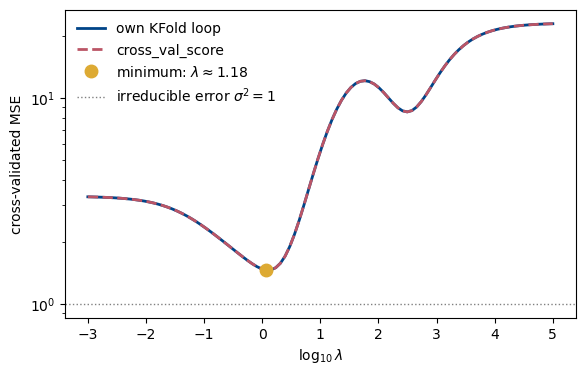

In [7]:
mse_sklearn = np.zeros(nlambdas)
for i, lmb in enumerate(lambdas):
    pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                         Ridge(alpha=lmb))
    scores = cross_val_score(pipe, x[:, np.newaxis], y, cv=kfold,
                             scoring="neg_mean_squared_error")
    mse_sklearn[i] = np.mean(-scores)

best = np.argmin(mse_sklearn)
print(f"best lambda {lambdas[best]:.4g}, cross-validated MSE {mse_sklearn[best]:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(np.log10(lambdas), mse_KFold, color=BLUE, lw=2, label="own KFold loop")
ax.plot(np.log10(lambdas), mse_sklearn, "--", color=RED, lw=2,
        label="cross_val_score")
ax.plot(np.log10(lambdas[best]), mse_sklearn[best], "o", color=YELLOW, ms=9,
        label=rf"minimum: $\lambda\approx{lambdas[best]:.3g}$")
ax.axhline(1.0, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2=1$")
ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}\lambda$")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.show()

**Reading the curve:** the minimum sits near $\lambda \approx 1$ with a CV-MSE
just above the known noise floor $\sigma^2 = 1$ — cross-validation has
recovered the irreducible error from 100 points. At $\lambda = 10^5$ every
coefficient is crushed, the model predicts the mean, and the error climbs to
the variance of $y$ itself.

### Step 3: how stable is the answer? Vary $k$

In [8]:
for k_ in (5, 10, 20):
    kf = KFold(n_splits=k_, shuffle=True, random_state=2026)
    mse_k = np.zeros(nlambdas)
    spread_k = np.zeros(nlambdas)
    for i, lmb in enumerate(lambdas):
        pipe = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(),
                             Ridge(alpha=lmb))
        scores = -cross_val_score(pipe, x[:, np.newaxis], y, cv=kf,
                                  scoring="neg_mean_squared_error")
        mse_k[i] = scores.mean()
        spread_k[i] = scores.std()
    b = np.argmin(mse_k)
    print(f"k = {k_:2d}: lambda* = {lambdas[b]:8.4g}   CV-MSE = {mse_k[b]:.4f}"
          f"   spread over folds = {spread_k[b]:.4f}")

k =  5: lambda* =    1.177   CV-MSE = 1.4569   spread over folds = 0.4198
k = 10: lambda* =    2.057   CV-MSE = 1.4708   spread over folds = 0.6525
k = 20: lambda* =    2.057   CV-MSE = 1.4590   spread over folds = 1.0812


k = 10: lambda* =    2.057   CV-MSE = 1.4708   spread over folds = 0.6525


k = 20: lambda* =    2.057   CV-MSE = 1.4590   spread over folds = 1.0812


The location of the minimum is stable across $k$ (the CV curve is flat near
its minimum), while the spread over folds — your error bar on the CV estimate —
changes with the fold size.

### Step 4: close the week's loop — CV over the polynomial degree

Finally, the week-35/Case-1 data set again, but now the *degree* is selected
by cross-validation (no bootstrap, no test set consumed).

CV selects degree 9 (CV-MSE 0.0198)


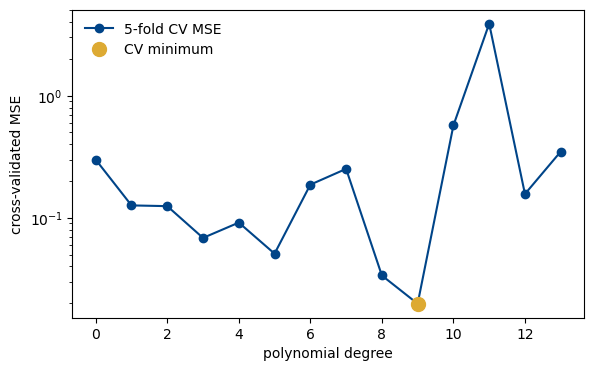

In [9]:
np.random.seed(2026)
n = 40
x1 = np.linspace(-3, 3, n).reshape(-1, 1)
y1 = np.exp(-x1**2) + 1.5 * np.exp(-(x1 - 2)**2) + np.random.normal(0, 0.1, x1.shape)

maxdegree = 14
kf = KFold(n_splits=5, shuffle=True, random_state=2026)
cv_mse = np.zeros(maxdegree)
for degree in range(maxdegree):
    pipe = make_pipeline(PolynomialFeatures(degree=degree),
                         LinearRegression(fit_intercept=False))
    scores = -cross_val_score(pipe, x1, y1.ravel(), cv=kf,
                              scoring="neg_mean_squared_error")
    cv_mse[degree] = scores.mean()

best_deg = np.argmin(cv_mse)
print(f"CV selects degree {best_deg} (CV-MSE {cv_mse[best_deg]:.4f})")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(range(maxdegree), cv_mse, "o-", color=BLUE, label="5-fold CV MSE")
ax.plot(best_deg, cv_mse[best_deg], "o", color=YELLOW, ms=10, label="CV minimum")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("cross-validated MSE")
ax.legend(frameon=False)
plt.show()

**Checkpoint:** cross-validation lands in the same broad degree window as the
bootstrap decomposition of Case 1 — two independent methods, one answer. That
agreement, not any single number, is what you should learn to look for.

---

## Extra (if time allows): the bootstrap and the central limit theorem

Monday's histogram figure, for completeness: the bootstrap distribution of the
sample mean of $10^4$ Gaussian numbers, against the CLT prediction
$\mathcal{N}(\mu, \sigma^2/n)$ of Eq. (2.24).

bootstrap std. error 0.15233   CLT sigma/sqrt(n) 0.15084


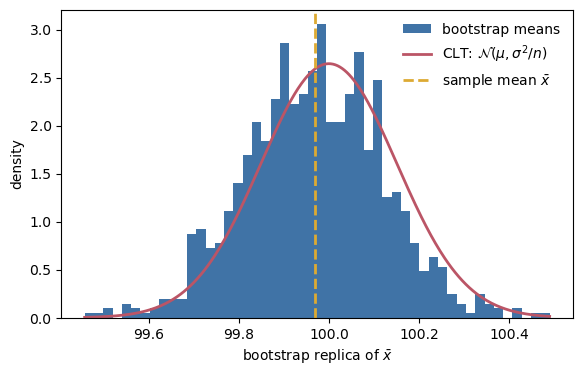

In [10]:
def bootstrap(data, statistic, k=1000, rng=None):
    """Bootstrap estimate of the distribution of a statistic."""
    rng = np.random.default_rng() if rng is None else rng
    n = len(data)
    replicas = np.empty(k)
    for i in range(k):
        sample = data[rng.integers(0, n, n)]   # draw n values with replacement
        replicas[i] = statistic(sample)
    return replicas


rng = np.random.default_rng(2026)
mu, sigma, ndata = 100.0, 15.0, 10000
data = rng.normal(mu, sigma, ndata)

t = bootstrap(data, np.mean, k=1000, rng=rng)
clt = np.std(data) / np.sqrt(ndata)
print(f"bootstrap std. error {np.std(t):.5f}   CLT sigma/sqrt(n) {clt:.5f}")

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.hist(t, bins=50, density=True, color=BLUE, alpha=0.75, label="bootstrap means")
grid = np.linspace(t.min(), t.max(), 400)
ax.plot(grid, norm.pdf(grid, mu, clt), color=RED, lw=2,
        label=r"CLT: $\mathcal{N}(\mu,\sigma^2/n)$")
ax.axvline(np.mean(data), color=YELLOW, lw=2, ls="--", label=r"sample mean $\bar{x}$")
ax.set_xlabel(r"bootstrap replica of $\bar{x}$")
ax.set_ylabel("density")
ax.legend(frameon=False)
plt.show()

Try replacing `np.mean` by `np.median`, or by a `lambda d: np.quantile(d, 0.9)`
— the bootstrap keeps working where no closed formula exists. That generality
is its whole point.

## Before you leave

- Make sure your group can state Eq. (2.47) and say which term each of today's
  experiments moved.
- Finish `exercisesweek36.ipynb` before **Friday September 4 at midnight**; the
  bootstrap and CV loops above are meant to be reused there (and in Project 1).
- Next Monday and week 38: the main focus shifts to *optimization* — gradient
  descent methods, from plain and steepest descent to stochastic gradient
  descent. We will also briefly mention the Bayesian reading of OLS, Ridge and
  Lasso (a Gaussian prior gives Ridge, a Laplace prior the Lasso).